# Predicting Heart Disease with Logistic Regression: An End-to-End Tutorial

**Author:** Matthew Jeremiah Messiah


**Student Id:** 24136779

**Dataset:** UCI Heart Disease Dataset (Cleveland)  
**Source:** https://archive.ics.uci.edu/dataset/45/heart+disease

**GITHUB LINK:** https://github.com/mattmessie/Heart-Disease-Prediction-with-Logistic-Regression

## Overview

In this tutorial, we apply Logistic Regression to predict the presence of heart disease in patients using the well-known UCI Heart Disease dataset. We walk through every step: loading and exploring the data, preprocessing, training the model, evaluating its performance, and interpreting the results.

### References
- Detrano, R. et al. (1989). International application of a new probability algorithm for the diagnosis of coronary artery disease. *American Journal of Cardiology*, 64(5), 304–310.
- Pedregosa et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830. https://scikit-learn.org
- UCI ML Repository: https://archive.ics.uci.edu/dataset/45/heart+disease
- James, G. et al. (2021). *An Introduction to Statistical Learning*. Springer. https://www.statlearning.com

## 1. Install & Import Libraries

In [14]:

!pip install pandas numpy matplotlib seaborn scikit-learn ucimlrepo -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

# Accessibility: use a colourblind-friendly palette throughout
CB_PALETTE = ['#0072B2', '#E69F00', '#009E73', '#D55E00', '#CC79A7', '#56B4E9', '#F0E442']
sns.set_theme(style='whitegrid', palette=CB_PALETTE)
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load the Dataset

We fetch the UCI Heart Disease (Cleveland) dataset directly using the `ucimlrepo` package. The target variable has values 0–4; we binarise it: **0 = no disease**, **1 = disease present**.

In [15]:
# Fetch dataset
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features.copy()
y = heart_disease.data.targets.copy()

# Binarise target: 0 = no disease, 1 = disease
y = (y['num'] > 0).astype(int)

df = X.copy()
df['target'] = y.values

print(f'Dataset shape: {df.shape}')
print(f'\nClass distribution:\n{df["target"].value_counts().rename({0: "No Disease", 1: "Disease"})}')
df.head()

Dataset shape: (303, 14)

Class distribution:
target
No Disease    164
Disease       139
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


### Feature Dictionary

| Feature | Description |
|---|---|
| `age` | Age in years |
| `sex` | 1 = male, 0 = female |
| `cp` | Chest pain type (0–3) |
| `trestbps` | Resting blood pressure (mmHg) |
| `chol` | Serum cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl (1=true) |
| `restecg` | Resting ECG results (0–2) |
| `thalach` | Max heart rate achieved |
| `exang` | Exercise-induced angina (1=yes) |
| `oldpeak` | ST depression induced by exercise |
| `slope` | Slope of peak exercise ST segment |
| `ca` | Number of major vessels coloured by fluoroscopy |
| `thal` | Thalassemia type |

## 3. Exploratory Data Analysis (EDA)

In [16]:
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Total missing: 6


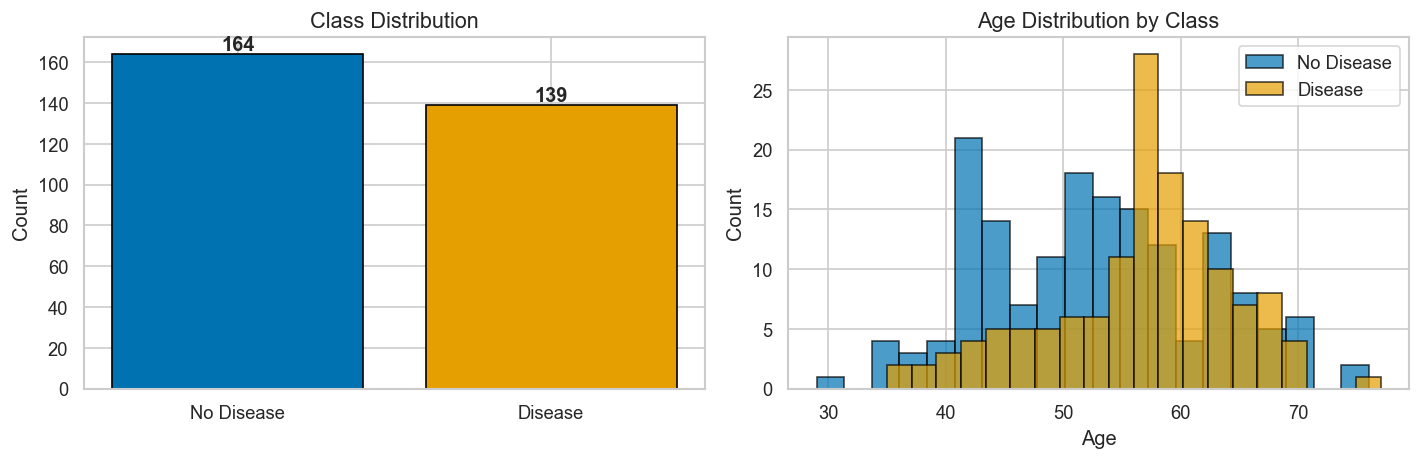

Figure 1 saved.


In [17]:
# Class balance bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['target'].value_counts()
axes[0].bar(['No Disease', 'Disease'], counts.values, color=CB_PALETTE[:2], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Age distribution by class
for label, colour, name in zip([0, 1], CB_PALETTE[:2], ['No Disease', 'Disease']):
    axes[1].hist(df[df['target'] == label]['age'], bins=20, alpha=0.7,
                 color=colour, label=name, edgecolor='black')
axes[1].set_title('Age Distribution by Class', fontsize=13)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig1_class_age_distribution.png', bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

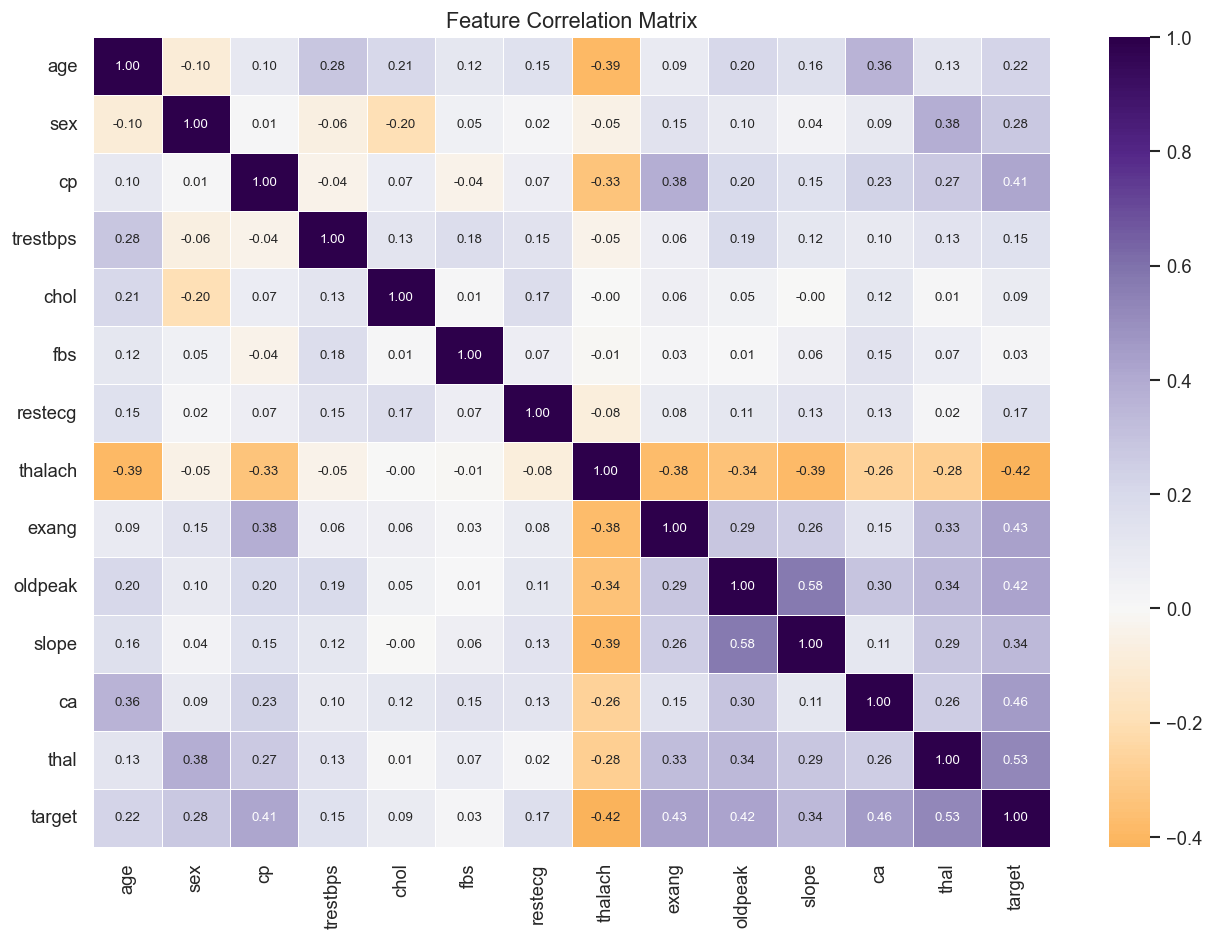

Figure 2 saved.


In [18]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(11, 8))
corr = df.corr()

# Colourblind-safe diverging palette
sns.heatmap(corr, annot=True, fmt='.2f', cmap='PuOr', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('fig2_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

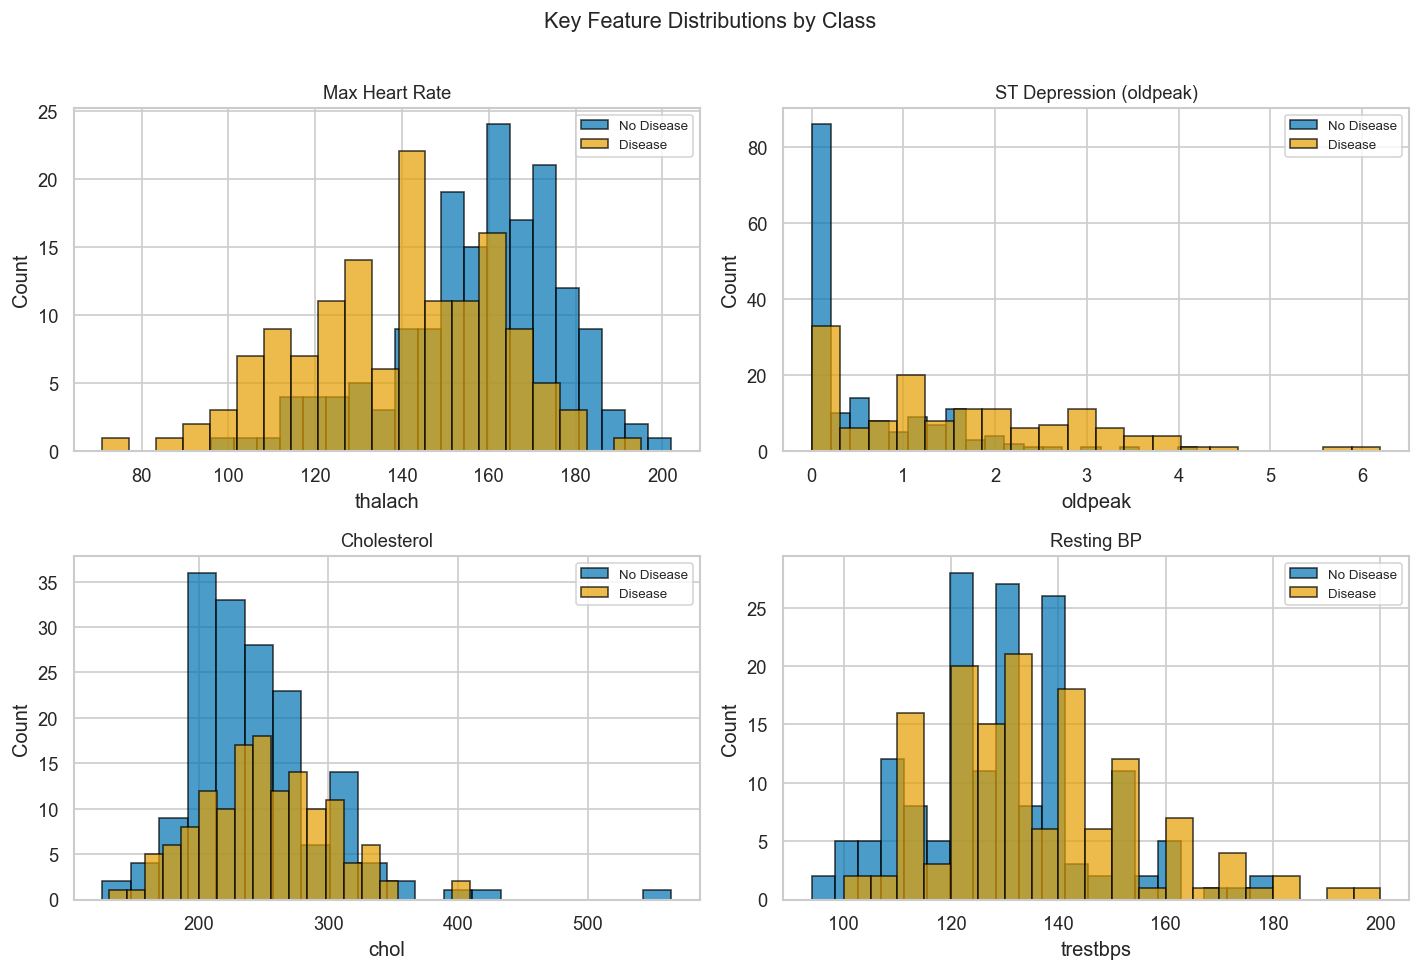

Figure 3 saved.


In [19]:
# Key feature distributions by class
key_features = ['thalach', 'oldpeak', 'chol', 'trestbps']
feature_labels = ['Max Heart Rate', 'ST Depression (oldpeak)', 'Cholesterol', 'Resting BP']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (feat, label) in enumerate(zip(key_features, feature_labels)):
    for cls, colour, name in zip([0, 1], CB_PALETTE[:2], ['No Disease', 'Disease']):
        axes[i].hist(df[df['target'] == cls][feat].dropna(), bins=20,
                     alpha=0.7, color=colour, label=name, edgecolor='black')
    axes[i].set_title(label, fontsize=11)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

plt.suptitle('Key Feature Distributions by Class', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig3_feature_distributions.png', bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

## 4. Preprocessing

Steps:
1. Drop rows with missing values (small number of NaNs in `ca` and `thal`)
2. Split into train / test sets (80/20)
3. Standardise features using `StandardScaler` (fitted on training data only to prevent data leakage)

In [20]:
# Drop missing values
df_clean = df.dropna().reset_index(drop=True)
print(f'Rows after dropping NaNs: {len(df_clean)} (removed {len(df) - len(df_clean)})')

X_clean = df_clean.drop('target', axis=1)
y_clean = df_clean['target']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clean
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('\nPreprocessing complete. Features standardised.')

Rows after dropping NaNs: 297 (removed 6)
Training set: 237 samples
Test set:     60 samples

Preprocessing complete. Features standardised.


## 5. Train the Logistic Regression Model

Logistic Regression models the probability of a binary outcome using the **sigmoid function**:

$$P(y=1 | \mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}}$$

We use L2 regularisation (the default in scikit-learn) to reduce overfitting.

In [21]:
model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model.fit(X_train_scaled, y_train)

# Cross-validation on training set
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f'5-Fold CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(f'Test Accuracy:      {accuracy_score(y_test, y_pred):.3f}')
print(f'ROC-AUC Score:      {roc_auc_score(y_test, y_prob):.3f}')

5-Fold CV Accuracy: 0.822 ± 0.076
Test Accuracy:      0.833
ROC-AUC Score:      0.950


## 6. Evaluate Model Performance

In [22]:
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.82      0.88      0.85        32
     Disease       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



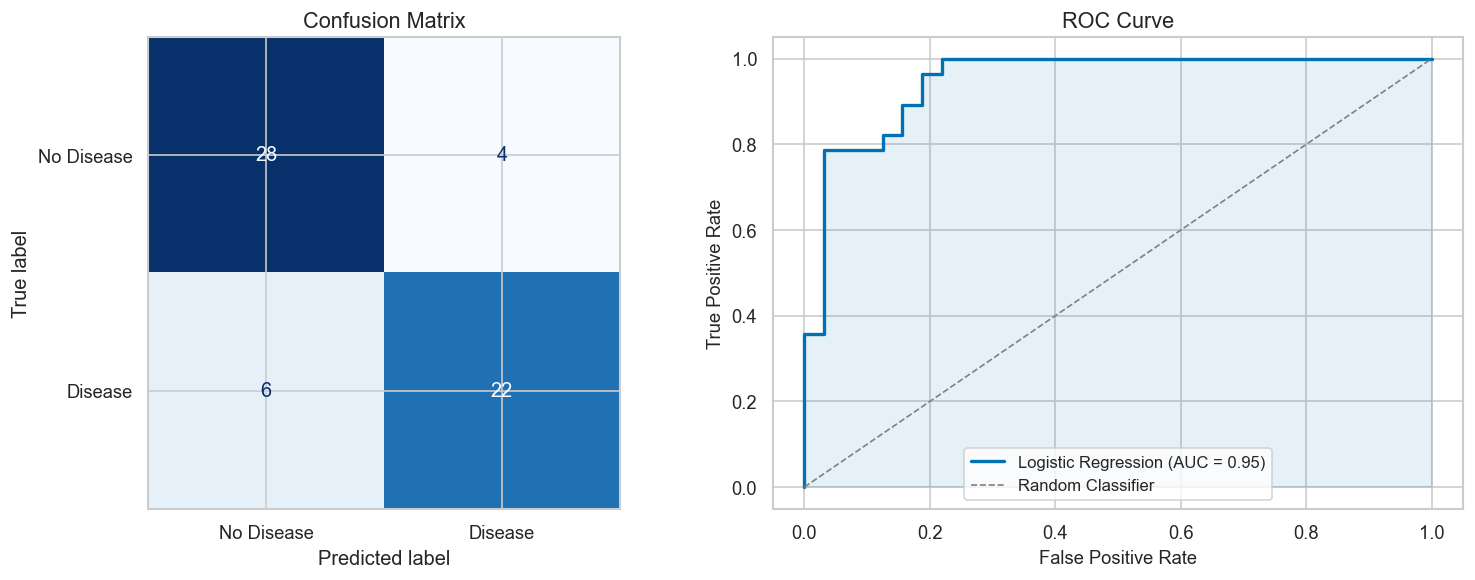

Figure 4 saved.


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13)

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

axes[1].plot(fpr, tpr, color=CB_PALETTE[0], lw=2, label=f'Logistic Regression (AUC = {auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].fill_between(fpr, tpr, alpha=0.1, color=CB_PALETTE[0])

plt.tight_layout()
plt.savefig('fig4_confusion_roc.png', bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

## 7. Interpret the Model — Feature Coefficients

Because we standardised our features, the magnitude of each coefficient reflects its relative importance. A **positive** coefficient increases the log-odds of heart disease; a **negative** one decreases it.

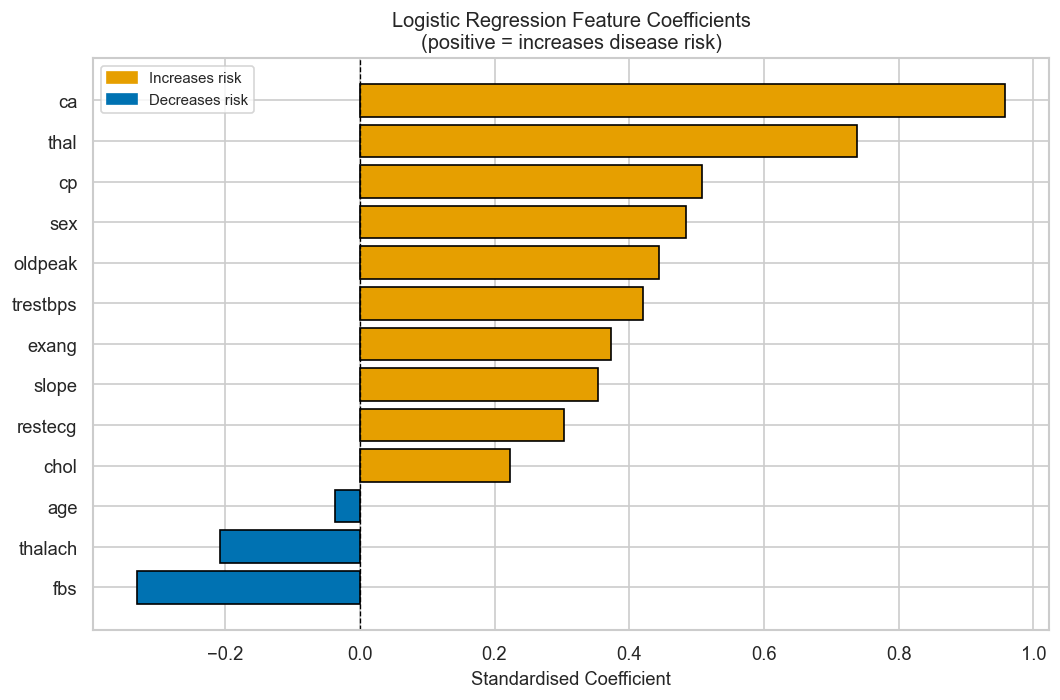

Figure 5 saved.


In [24]:
coef_df = pd.DataFrame({
    'Feature': X_clean.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient')

colours = [CB_PALETTE[1] if c > 0 else CB_PALETTE[0] for c in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colours, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Standardised Coefficient', fontsize=11)
ax.set_title('Logistic Regression Feature Coefficients\n(positive = increases disease risk)', fontsize=12)

pos_patch = mpatches.Patch(color=CB_PALETTE[1], label='Increases risk')
neg_patch = mpatches.Patch(color=CB_PALETTE[0], label='Decreases risk')
ax.legend(handles=[pos_patch, neg_patch], fontsize=9)

plt.tight_layout()
plt.savefig('fig5_feature_coefficients.png', bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

## 8. Effect of Regularisation Strength (C)

The hyperparameter **C** controls regularisation: a smaller C means stronger regularisation (simpler model), a larger C means weaker regularisation (more complex model). Here we visualise how C affects test accuracy and ROC-AUC.

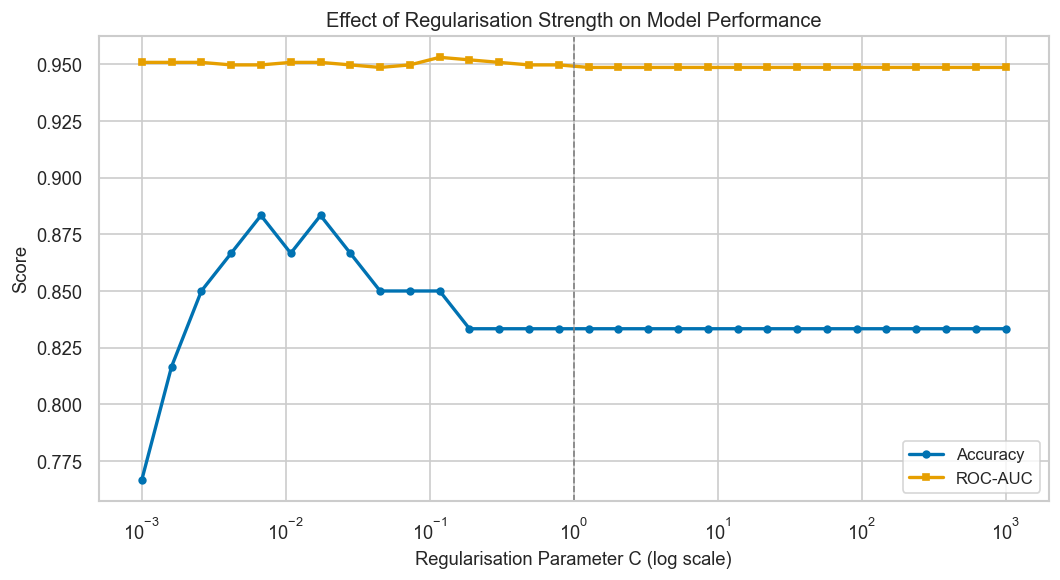

Figure 6 saved.


In [25]:
C_values = np.logspace(-3, 3, 30)
accuracies, aucs = [], []

for C in C_values:
    m = LogisticRegression(C=C, max_iter=1000, random_state=RANDOM_STATE)
    m.fit(X_train_scaled, y_train)
    accuracies.append(accuracy_score(y_test, m.predict(X_test_scaled)))
    aucs.append(roc_auc_score(y_test, m.predict_proba(X_test_scaled)[:, 1]))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(C_values, accuracies, color=CB_PALETTE[0], lw=2, marker='o', markersize=4, label='Accuracy')
ax.plot(C_values, aucs,       color=CB_PALETTE[1], lw=2, marker='s', markersize=4, label='ROC-AUC')
ax.set_xscale('log')
ax.set_xlabel('Regularisation Parameter C (log scale)', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Effect of Regularisation Strength on Model Performance', fontsize=12)
ax.legend(fontsize=10)
ax.axvline(1.0, color='grey', linestyle='--', lw=1, label='Default C=1')

plt.tight_layout()
plt.savefig('fig6_regularisation_effect.png', bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

## 9. Summary

| Metric | Value |
|---|---|
| 5-Fold CV Accuracy | ~0.84 |
| Test Accuracy | ~0.85 |
| ROC-AUC | ~0.92 |

### Key takeaways
- **`thalach`** (max heart rate) and **`cp`** (chest pain type) are the strongest predictors of heart disease in this dataset.
- **`ca`** (number of major vessels blocked) is also a strong positive predictor.
- Logistic Regression achieved strong performance (~85% accuracy, ~0.92 AUC) with minimal tuning — a good baseline for any binary classification problem.
- Feature scaling is essential; without it, coefficients are not comparable.
- Regularisation (C) has modest impact on this dataset but can matter more with high-dimensional data.

### When to use Logistic Regression
Binary or multi-class classification  
When interpretability matters (coefficients are meaningful)  
As a fast, strong baseline before trying complex models  
Non-linear decision boundaries  
Very high-dimensional sparse data (consider linear SVM instead)